In [1]:
!pip install icosphere

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for icosphere: filename=icosphere-0.1.3-py3-none-any.whl size=15170 sha256=6a4abaa1f1d4d59de51f6180352dad3733fa1e412a6fa0afe944e58b977aed10
  Stored in directory: /Users/Julie/Library/Caches/pip/wheels/ba/a5/ec/a859d035a59a6c08870f7d8a4190465bca1c7d26d6466bdc7b
Successfully built icosphere


In [2]:
from icosphere import icosphere
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import mpl_toolkits.mplot3d 

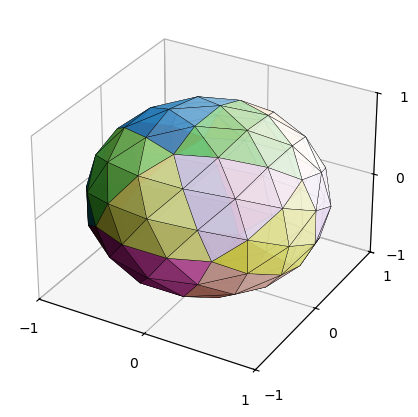

In [5]:
nu = 3

fig, ax = plt.subplots(figsize=(5,5), subplot_kw={'projection': '3d'})

vertices, faces = icosphere(nu=nu)
# basic mesh color, divided in 20 groups (one for each original face)
jet = matplotlib.cm.tab20(np.linspace(0,1,20))
jet = np.tile(jet[:,:3], (1, faces.shape[0]//20))
jet = jet.reshape(faces.shape[0], 1, 3)

# computing face shading intensity based on face normals  
face_normals = np.cross(vertices[faces[:,1]]-vertices[faces[:,0]], 
                        vertices[faces[:,2]]-vertices[faces[:,0]])
face_normals /= np.sqrt(np.sum(face_normals**2, axis=1, keepdims=True))               
light_source = matplotlib.colors.LightSource(azdeg=60, altdeg=30)
intensity = light_source.shade_normals(face_normals)

# blending face colors and face shading intensity
rgb = light_source.blend_hsv(rgb=jet, intensity=intensity.reshape(-1,1,1))   

# adding alpha value, may be left out
rgba = np.concatenate((rgb, 0.9*np.ones(shape=(rgb.shape[0],1,1))), axis=2) 

# creating mesh with given face colors
poly = mpl_toolkits.mplot3d.art3d.Poly3DCollection(vertices[faces])
poly.set_facecolor(rgba.reshape(-1,4)) 
poly.set_edgecolor('black')
poly.set_linewidth(0.25)

ax.add_collection3d(poly) 

ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)

ax.set_xticks([-1,0,1])
ax.set_yticks([-1,0,1])
ax.set_zticks([-1,0,1])

plt.show()